Este notebook explora técnicas visualização de dados a partir de informações públicas sobre o volume de passageiros aéreos em diversos países entre 1970 e 2023. O objetivo é testar conceitos mais avançados de visualização de dados. Como complemento, o notebook também traz uma exploração introdutória da biblioteca CausalImpact (Google, 2015), utilizada para estimar os efeitos da pandemia sobre o volume global de passageiros aéreos.

Fonte de Dados: 'Multiple sources compiled by World Bank (2024) – processed by Our World in Data. "Air passengers" [dataset]. International Civil Aviation Organization (via World Bank), "World Development Indicators" [original data]. Retrieved January 23, 2025 from https://ourworldindata.org/grapher/air-passengers-carried

In [1]:
# preparação do notebook
import sys
import os

sys.path.append(os.path.abspath('..'))

import warnings
import pandas as pd
import requests
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import MaxNLocator
from matplotlib.patches import FancyArrowPatch, Circle
from highlight_text import fig_text, ax_text

pd.set_option('display.float_format', lambda x: '%.2f' % x)
warnings.filterwarnings('ignore')
plt.rcParams["figure.dpi"] = 150

%load_ext autoreload
%autoreload 2

### **Leitura e Tratamento dos Dados**

Os dados são fornecidos pelo **Banco Mundial** a partir dos registros anuais da **OACI** (Organização Internacional de Aviação Civil). Cada linha representa o total de passageiros transportados em voos domésticos e internacionais em um país, para um determinado ano — cobrindo o período de **1970 a 2023**.

O dataset original contém registros de **198 países**, mas a cobertura temporal varia: alguns países possuem dados apenas para os anos mais recentes. A próxima etapa trata esse problema.

In [2]:
# leitura dos dados
df = pd.read_csv(
    "https://ourworldindata.org/grapher/air-passengers-carried.csv?v=1&csvType=full&useColumnShortNames=true",
    storage_options={"User-Agent": "Our World In Data data fetch/1.0"},
)

metadata = requests.get(
    "https://ourworldindata.org/grapher/air-passengers-carried.metadata.json?v=1&csvType=full&useColumnShortNames=true"
).json()

In [3]:
metadata["columns"]["is_air_psgr"]

{'titleShort': 'Air transport, passengers carried',
 'titleLong': 'Air transport, passengers carried',
 'unit': '',
 'timespan': '1970-2023',
 'type': 'Numeric',
 'owidVariableId': 1204636,
 'shortName': 'is_air_psgr',
 'lastUpdated': '2026-02-27',
 'nextUpdate': '2027-02-27',
 'citationShort': 'International Civil Aviation Organization (ICAO), via World Bank (2026) – processed by Our World in Data',
 'citationLong': 'International Civil Aviation Organization (ICAO), via World Bank (2026) – processed by Our World in Data. “Air transport, passengers carried” [dataset]. International Civil Aviation Organization (ICAO), via World Bank, “World Development Indicators 125” [original data].',
 'fullMetadata': 'https://api.ourworldindata.org/v1/indicators/1204636.metadata.json'}

In [4]:
# visualizando dados
df.head()

,entity,code,year,is_air_psgr
0,Afghanistan,AFG,1970,84700.00
1,Afghanistan,AFG,1971,97400.00
2,Afghanistan,AFG,1972,104900.00
3,Afghanistan,AFG,1973,96600.00
4,Afghanistan,AFG,1974,96100.00


In [5]:
# verificando se o dataset contém dados dos anos para os países
# iremos utilizar para a visualização apenas os países com todos os anos
count = df.value_counts("entity")
count

entity
Algeria           54
Bolivia           54
Belgium           54
Austria           54
Australia         54
                  ..
Gambia            10
Eritrea            6
American Samoa     5
Aruba              2
Guam               2
Name: count, Length: 198, dtype: int64

In [6]:
# filtrando apenas os países todos os anos registrados
df = df.loc[df["entity"].isin(count[count == count.max()].index)]
df.entity.unique()

array(['Algeria', 'Argentina', 'Australia', 'Austria', 'Belgium',
       'Bolivia', 'Brazil', 'Bulgaria', 'Burkina Faso', 'Cameroon',
       'Canada', 'Chile', 'Colombia', 'Costa Rica', 'Cuba', 'Cyprus',
       'Czechia', 'Ecuador', 'Egypt', 'El Salvador', 'Ethiopia',
       'European Union (27)', 'Finland', 'France', 'Germany', 'Greece',
       'High-income countries', 'Hungary', 'Iceland', 'India',
       'Indonesia', 'Iran', 'Ireland', 'Israel', 'Italy', 'Japan',
       'Jordan', 'Kenya', 'Kuwait', 'Laos',
       'Latin America and Caribbean (WB)', 'Lebanon', 'Libya',
       'Lower-middle-income countries', 'Luxembourg', 'Madagascar',
       'Malawi', 'Malaysia', 'Malta', 'Mauritania', 'Mauritius', 'Mexico',
       'Middle East, North Africa, Afghanistan and Pakistan (WB)',
       'Morocco', 'Myanmar', 'Nepal', 'Netherlands', 'New Zealand',
       'Nigeria', 'North America (WB)', 'Pakistan', 'Panama', 'Paraguay',
       'Peru', 'Philippines', 'Poland', 'Portugal', 'Romania',
       

Foram mantidos apenas os países com registros em todos os anos do período (1970–2023). Esse filtro garante que a série temporal agregada seja comparável ao longo do tempo — evitando distorções causadas pela entrada ou saída de países da amostra.

### **Visualização**

In [7]:
# primeira visualização: volume total de passageiros por ano
grouped_df = df.groupby("year", as_index=False).agg({"is_air_psgr": "sum"})

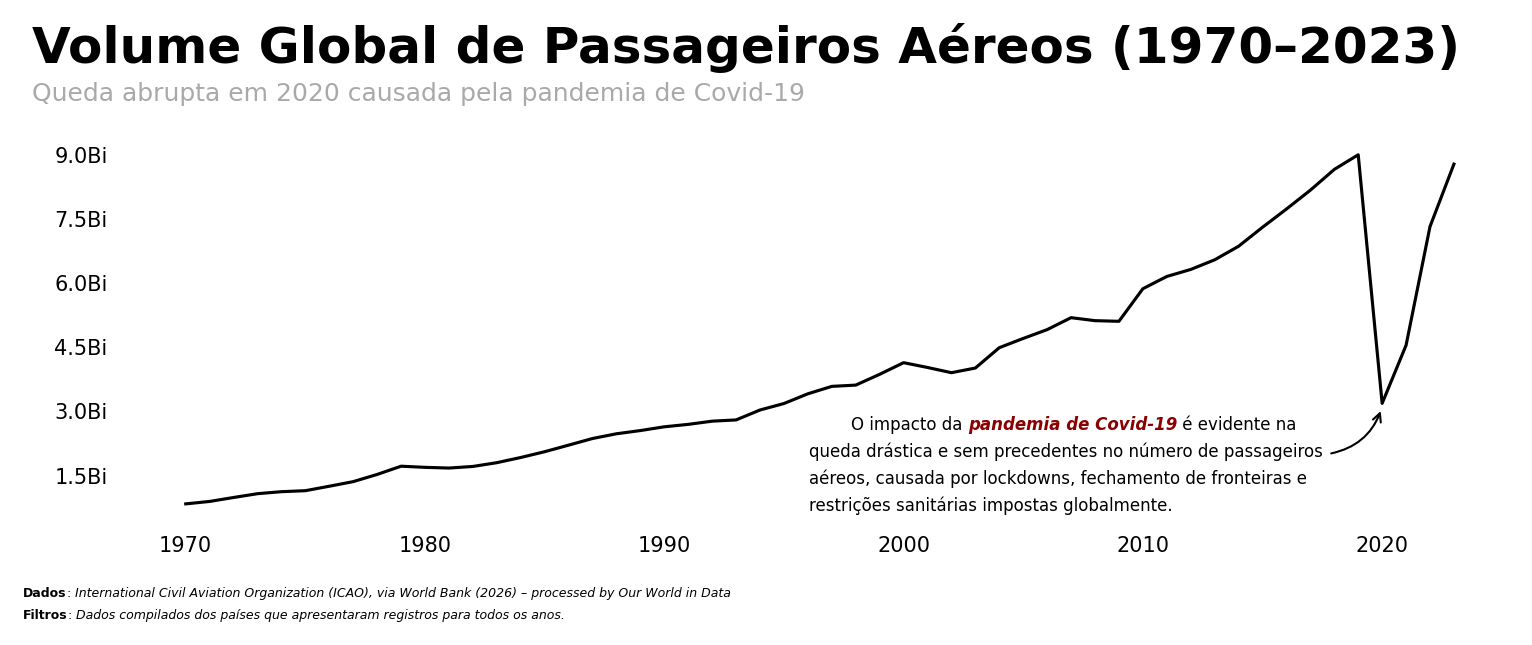

In [8]:
# função auxiliar
def y_ticks_formatter(value, _):
    abs_value = abs(value)
    if abs_value >= 1_000_000_000_000:
        return f"{value / 1_000_000_000_000:.1f}Ti"
    elif abs_value >= 1_000_000_000:
        return f"{value / 1_000_000_000:.1f}Bi"
    elif abs_value >= 1_000_000:
        return f"{value / 1_000_000:.1f}M"
    elif abs_value >= 1_000:
        return f"{value / 1_000:.1f}K"
    return str(int(value))


fig, ax = plt.subplots(figsize=(12, 4))
fig.subplots_adjust(top=0.78, bottom=0.14)

ax.plot(grouped_df["year"], grouped_df["is_air_psgr"], color="black")

for spine in ax.spines.values():
    spine.set_visible(False)


ax.yaxis.set_major_formatter(FuncFormatter(y_ticks_formatter))
ax.yaxis.set_major_locator(MaxNLocator(nbins=7))
ax.tick_params(left=False, bottom=False)

fig_text(
    x=0.075,
    y=0.97,
    s=(
        "Volume Global de Passageiros Aéreos (1970–2023)\n"
        "<Queda abrupta em 2020 causada pela pandemia de Covid-19>"
    ),
    color="black",
    fontweight="bold",
    fontsize=24,
    highlight_textprops=[{"fontsize": 12, "color": "darkgrey", "fontweight": "normal"}],
    ha="left",
)

arrow = FancyArrowPatch(
    posA=(2017.7, 2e9),
    posB=(2020, 3.1e9),
    arrowstyle="->",
    connectionstyle="arc3,rad=.30",
    color="black",
    lw=1,
    mutation_scale=10,
)
ax.add_patch(arrow)

fig_text(
    x=0.07,
    y=0.03,
    s=(
        f"<Dados>: <{metadata['columns']['is_air_psgr']['citationShort']}>\n"
        "<Filtros>: <Dados compilados dos países que apresentaram registros para todos os anos.>"
    ),
    color="black",
    ha="left",
    fontsize=6,
    highlight_textprops=[
        {"fontweight": "bold"},
        {"fontstyle": "italic"},
        {"fontweight": "bold"},
        {"fontstyle": "italic"},
    ],
)

fig_text(
    x=0.495,
    y=0.315,
    s=(
        "            O impacto da <pandemia de Covid-19> é evidente na \n"
        "    queda drástica e sem precedentes no número de passageiros\n"
        "    aéreos, causada por lockdowns, fechamento de fronteiras e \n"
        "    restrições sanitárias impostas globalmente."
    ),
    color="black",
    ha="left",
    fontsize=8,
    highlight_textprops=[
        {"fontstyle": "italic", "fontweight": "bold", "color": "darkred"},
    ],
)

plt.show()

O gráfico mostra tendência de crescimento no tráfego aéreo global. A pandemia de Covid-19 causou uma interrupção abrupta no volume de passageiros.

Com intuito de explorar a ferramenta, será utilizado a biblioteca CausalImpact (Google, 2015) para quantificar o impacto.

### **CausalImpact: Estimativa do Impacto da Pandemia (2020–2023)**

O **CausalImpact** é um método de inferência causal desenvolvido pelo Google ([Brodersen et al., 2015](https://research.google/pubs/pub41854/)) para estimar o efeito de uma intervenção em séries temporais.

A ideia é modelar a série histórica (período pré-intervenção) e projetar um cenário _contrafactual_, ou seja: o cenário mais provável de ter acontecido caso não houvesse a intervenção (no caso analisado é a pandemia). O impacto estimado em cada ponto do tempo é:

$$\text{efeito}(t) = y_{\text{obs}}(t) - \hat{y}_{\text{contrafactual}}(t)$$

#### Configuração do experimento

| Parâmetro | Valor |
|-----------|-------|
| Período pré-intervenção | 1970 – 2019 |
| Período pós-intervenção | 2020 – 2023 |
| Intervenção | Pandemia de Covid-19 |
| Covariáveis | Tendência linear e quadrática |

In [9]:
from causalimpact import CausalImpact
from pandas.api import types as ptypes
from scipy import stats as st

pd.core.dtypes.common.is_datetime_or_timedelta_dtype = (
    lambda x: ptypes.is_datetime64_any_dtype(x) or ptypes.is_timedelta64_dtype(x)
)

impact_df = grouped_df.set_index("year")[["is_air_psgr"]].copy()
impact_df["trend"] = range(len(impact_df))
impact_df["trend_sq"] = impact_df["trend"] ** 2

pre_period = [1970, 2019]
post_period = [2020, 2023]

impact = CausalImpact(impact_df, pre_period, post_period)
impact.run()

# p-valor e probabilidade de efeito causal
post_inf = impact.inferences.loc[post_period[0] : post_period[1]]
mean_pred = post_inf["point_pred"].mean()
mean_upper = post_inf["point_pred_upper"].mean()
std_pred = (mean_upper - mean_pred) / 1.96
z_score = -mean_pred / std_pred
p_value = st.norm.cdf(z_score)
prob_causal = 1 - p_value

p_val_str = "p_valor ≤ 0.001" if p_value < 0.001 else f"p_valor = {p_value:.3f}"

print(f"p-valor      : {p_value:.4f}")
print(f"Prob. causal : {prob_causal:.2%}")

g++ not available, if using conda: `conda install gxx`


p-valor      : 0.0000
Prob. causal : 100.00%


O *p-valor* é calculado a partir da distribuição do efeito médio estimado no pós-período. O desvio padrão é inferido diretamente do intervalo de confiança de 95% retornado pelo modelo:

$$\sigma = \frac{\hat{y}_{\text{upper}} - \hat{y}_{\text{pred}}}{1{,}96}$$

Em seguida, calcula-se o _z-score_ sob a hipótese nula de que o efeito é zero (ou seja, que a pandemia não teve impacto):

$$z = \frac{0 - \hat{y}_{\text{pred}}}{\sigma} \implies p = \Phi(z)$$

Um _p-valor_ próximo de zero indica que é improvável que a diferença observada entre a série real e a projeção contrafactual tenha ocorrido por acaso. A probabilidade de efeito causal é o complementar $1 - p$.

---
*Os cálculos foram replicados do método summary() da bibilioteca apenas para facilitar o uso posterior na visualização.

In [10]:
# dados completos para plot
plot_df = (
    impact_df[["is_air_psgr"]]
    .join(impact.inferences[["point_pred", "point_pred_lower", "point_pred_upper"]])
    .reset_index()
)

# dados do período pós-intervenção
post_plot = plot_df[plot_df["year"].between(post_period[0], post_period[1])].copy()

post_plot["point_effects"] = post_plot["is_air_psgr"] - post_plot["point_pred"]
post_plot["point_effects_lower"] = (
    post_plot["is_air_psgr"] - post_plot["point_pred_upper"]
)
post_plot["point_effects_upper"] = (
    post_plot["is_air_psgr"] - post_plot["point_pred_lower"]
)
post_plot["cum_effects"] = post_plot["point_effects"].cumsum()
post_plot["cum_effects_lower"] = post_plot["point_effects_lower"].cumsum()
post_plot["cum_effects_upper"] = post_plot["point_effects_upper"].cumsum()

# métricas de impacto: impacto absoluto e taxa de impacto
impacto_abs = post_plot["is_air_psgr"].sum() - post_plot["point_pred"].sum()
impacto_pct = (impacto_abs / post_plot["point_pred"].sum()) * 100

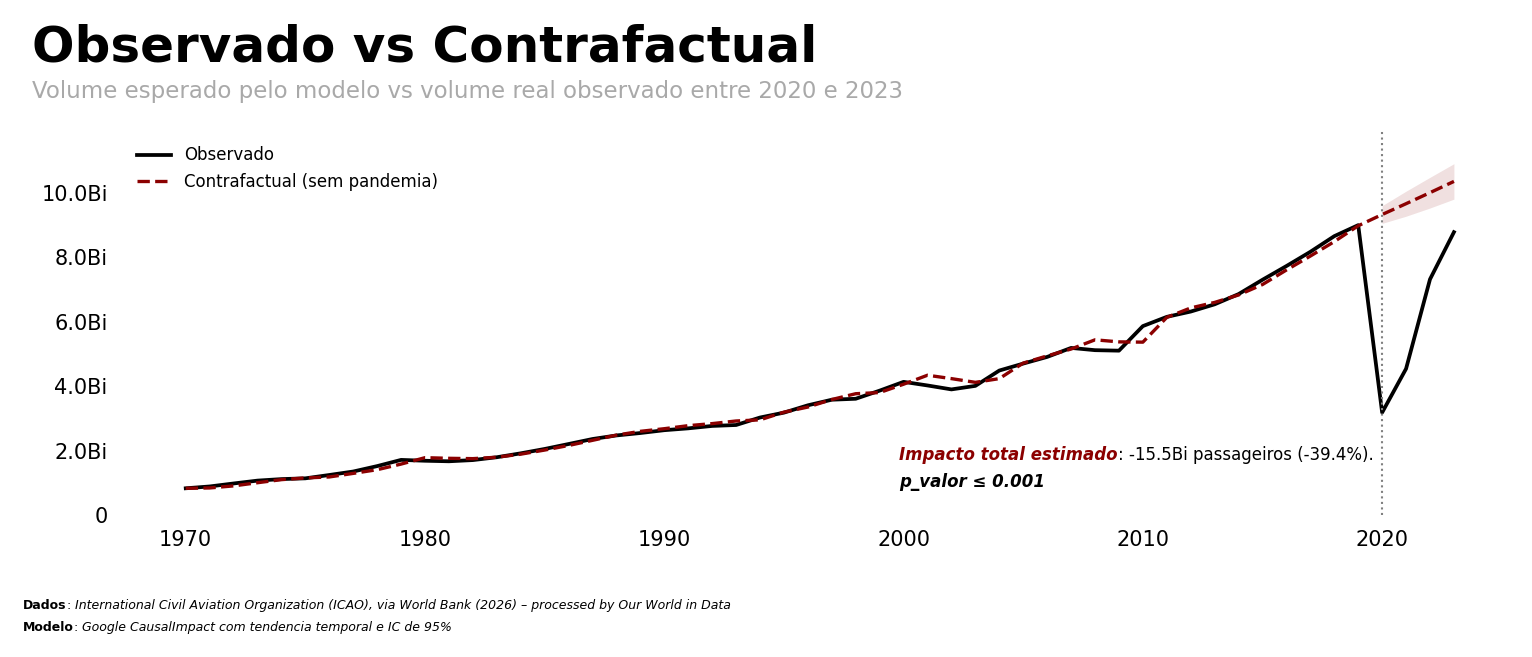

In [11]:
y_max = max(plot_df["is_air_psgr"].max(), plot_df["point_pred"].max())

fig, ax = plt.subplots(figsize=(12, 4))
fig.subplots_adjust(top=0.80, bottom=0.16)

fig_text(
    x=0.075,
    y=0.98,
    s="Observado vs Contrafactual\n<Volume esperado pelo modelo vs volume real observado entre 2020 e 2023>",
    color="black",
    fontweight="bold",
    fontsize=24,
    ha="left",
    highlight_textprops=[{"fontsize": 11, "color": "darkgrey", "fontweight": "normal"}],
)

ax.plot(plot_df["year"], plot_df["is_air_psgr"], color="black", lw=1.8, label="Observado")
ax.plot(
    plot_df["year"],
    plot_df["point_pred"],
    color="darkred",
    lw=1.6,
    linestyle="--",
    label="Contrafactual (sem pandemia)",
)
ax.fill_between(
    post_plot["year"],
    post_plot["point_pred_lower"].clip(0, y_max * 1.15),
    post_plot["point_pred_upper"].clip(0, y_max * 1.15),
    color="darkred",
    alpha=0.12,
    linewidth=0,
)
ax.axvline(post_period[0], color="grey", lw=1, linestyle=":")

for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_ylim(0, y_max * 1.15)
ax.yaxis.set_major_formatter(FuncFormatter(y_ticks_formatter))
ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
ax.tick_params(left=False, bottom=False)
ax.legend(frameon=False, loc="upper left", fontsize=8)

fig_text(
    x=0.82,
    y=0.275,
    s=f"<Impacto total estimado>: {y_ticks_formatter(impacto_abs, None)} passageiros ({impacto_pct:.1f}%).\n<{p_val_str}>",
    color="black",
    ha="right",
    fontsize=8,
    highlight_textprops=[
        {"fontstyle": "italic", "fontweight": "bold", "color": "darkred"},
        {"fontstyle": "italic", "fontweight": "bold"},
    ],
)
fig_text(
    x=0.07,
    y=0.02,
    s=f"<Dados>: <{metadata['columns']['is_air_psgr']['citationShort']}>\n<Modelo>: <Google CausalImpact com tendencia temporal e IC de 95%>",
    color="black",
    ha="left",
    fontsize=6,
    highlight_textprops=[
        {"fontweight": "bold"},
        {"fontstyle": "italic"},
        {"fontweight": "bold"},
        {"fontstyle": "italic"},
    ],
)
plt.show()

O gráfico compara a série _real (linha preta)_ com a projeção _contrafactual (linha vermelha tracejada)_. A região sombreada representa o _intervalo de confiança de 95%_ da previsão.

A linha vertical pontilhada marca o início do período de intervenção (2020).

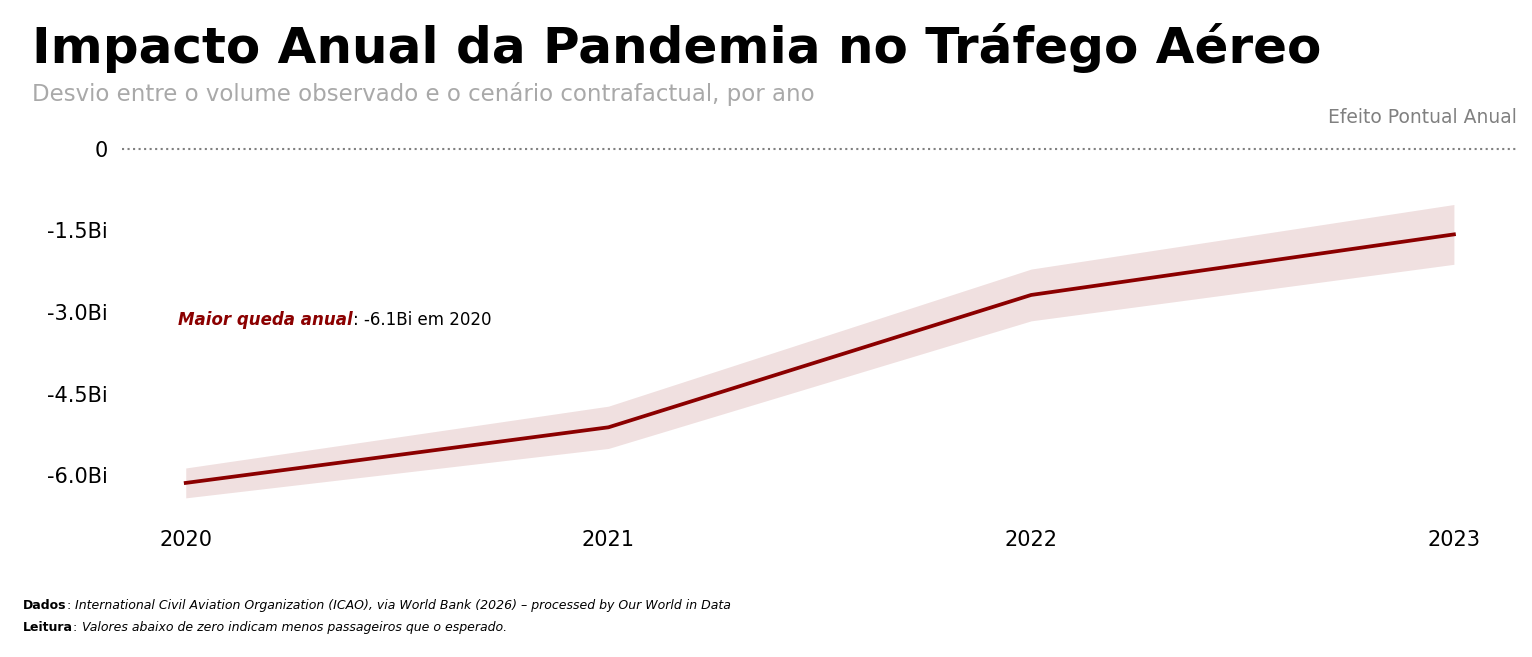

In [12]:
ano_pior = int(post_plot.loc[post_plot["point_effects"].idxmin(), "year"])
efeito_pior = y_ticks_formatter(post_plot["point_effects"].min(), None)

fig, ax = plt.subplots(figsize=(12, 4))
fig.subplots_adjust(top=0.80, bottom=0.16)

fig_text(
    x=0.075,
    y=0.98,
    s="Impacto Anual da Pandemia no Tráfego Aéreo\n<Desvio entre o volume observado e o cenário contrafactual, por ano>",
    color="black",
    fontweight="bold",
    fontsize=24,
    ha="left",
    highlight_textprops=[{"fontsize": 11, "color": "darkgrey", "fontweight": "normal"}],
)

ax.plot(post_plot["year"], post_plot["point_effects"], color="darkred", lw=1.8)
ax.fill_between(
    post_plot["year"],
    post_plot["point_effects_lower"],
    post_plot["point_effects_upper"],
    color="darkred",
    alpha=0.12,
    linewidth=0,
)
ax.axhline(0, color="grey", lw=1, linestyle=":")

for spine in ax.spines.values():
    spine.set_visible(False)
ax.yaxis.set_major_formatter(FuncFormatter(y_ticks_formatter))
ax.yaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.tick_params(left=False, bottom=False)
ax.set_title("Efeito Pontual Anual", fontsize=9, loc="right", pad=4, color="grey")

fig_text(
    x=0.33,
    y=0.5,
    s=f"<Maior queda anual>: {efeito_pior} em {ano_pior}",
    color="black",
    ha="right",
    fontsize=8,
    highlight_textprops=[
        {"fontstyle": "italic", "fontweight": "bold", "color": "darkred"}
    ],
)
fig_text(
    x=0.07,
    y=0.02,
    s=f"<Dados>: <{metadata['columns']['is_air_psgr']['citationShort']}>\n<Leitura>: <Valores abaixo de zero indicam menos passageiros que o esperado.>",
    color="black",
    ha="left",
    fontsize=6,
    highlight_textprops=[
        {"fontweight": "bold"},
        {"fontstyle": "italic"},
        {"fontweight": "bold"},
        {"fontstyle": "italic"},
    ],
)
plt.show()

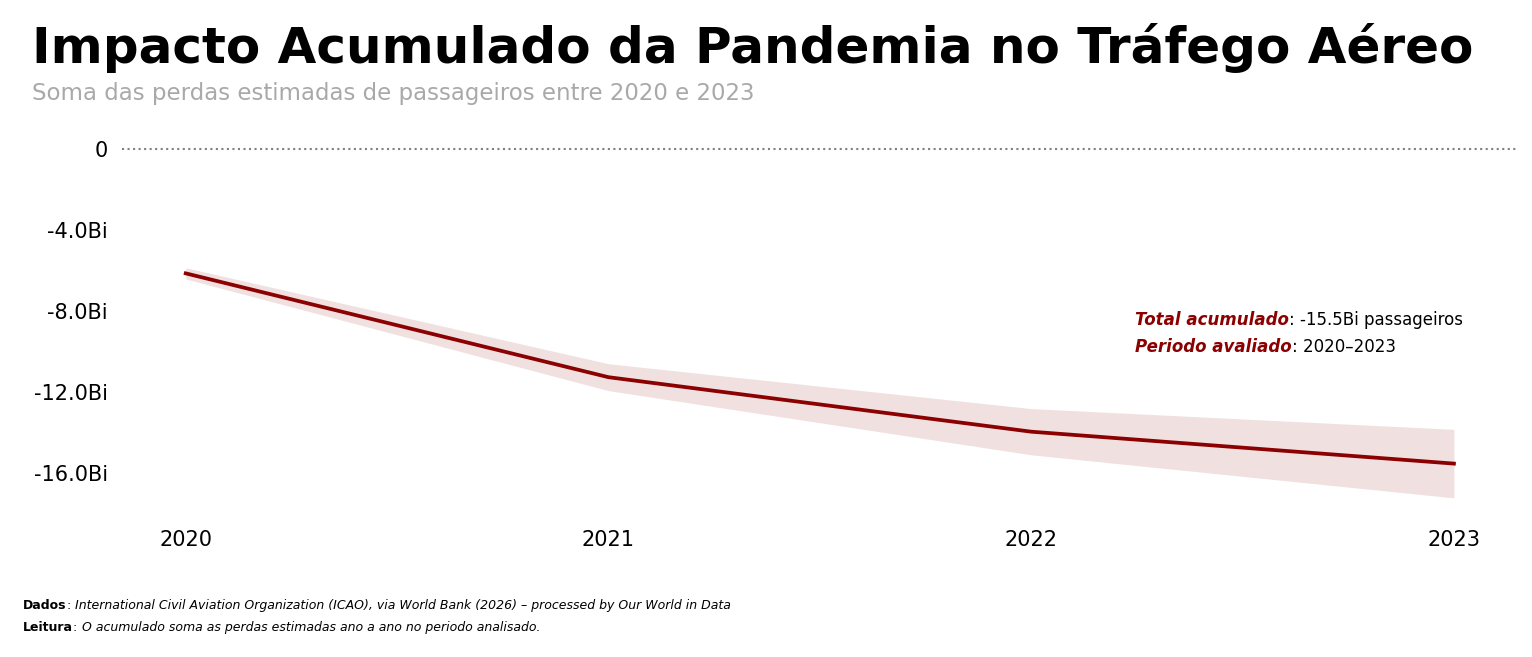

In [13]:
cum_total = y_ticks_formatter(post_plot["cum_effects"].iloc[-1], None)

fig, ax = plt.subplots(figsize=(12, 4))
fig.subplots_adjust(top=0.80, bottom=0.16)

fig_text(
    x=0.075,
    y=0.98,
    s="Impacto Acumulado da Pandemia no Tráfego Aéreo\n<Soma das perdas estimadas de passageiros entre 2020 e 2023>",
    color="black",
    fontweight="bold",
    fontsize=24,
    ha="left",
    highlight_textprops=[{"fontsize": 11, "color": "darkgrey", "fontweight": "normal"}],
)

ax.plot(post_plot["year"], post_plot["cum_effects"], color="darkred", lw=1.8)
ax.fill_between(
    post_plot["year"],
    post_plot["cum_effects_lower"],
    post_plot["cum_effects_upper"],
    color="darkred",
    alpha=0.12,
    linewidth=0,
)
ax.axhline(0, color="grey", lw=1, linestyle=":")

for spine in ax.spines.values():
    spine.set_visible(False)
ax.yaxis.set_major_formatter(FuncFormatter(y_ticks_formatter))
ax.yaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.tick_params(left=False, bottom=False)

fig_text(
    x=0.87,
    y=0.5,
    s=f"<Total acumulado>: {cum_total} passageiros\n<Periodo avaliado>: {post_period[0]}–{post_period[1]}",
    color="black",
    ha="right",
    fontsize=8,
    highlight_textprops=[
        {"fontstyle": "italic", "fontweight": "bold", "color": "darkred"},
        {"fontstyle": "italic", "fontweight": "bold", "color": "darkred"},
    ],
)
fig_text(
    x=0.07,
    y=0.02,
    s=f"<Dados>: <{metadata['columns']['is_air_psgr']['citationShort']}>\n<Leitura>: <O acumulado soma as perdas estimadas ano a ano no periodo analisado.>",
    color="black",
    ha="left",
    fontsize=6,
    highlight_textprops=[
        {"fontweight": "bold"},
        {"fontstyle": "italic"},
        {"fontweight": "bold"},
        {"fontstyle": "italic"},
    ],
)
plt.show()

### **Fontes e Inspirações**
Dados: https://ourworldindata.org/grapher/air-passengers-carried?tab=chart&country=~BRA#sources-and-processing \
Estilização: https://python-graph-gallery.com/web-stacked-charts/ \
Modelo: https://research.google/pubs/inferring-causal-impact-using-bayesian-structural-time-series-models/